In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [7]:
class BatsmanState(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int 

    strike_rate : float
    balls_per_boundary : float
    boundaries_percent : float
    summary : str

In [20]:
def calculate_strike_rate(state: BatsmanState):
    strike_rate= (state['runs'] / state['balls']) * 100
    return {'strike_rate': strike_rate}

In [13]:
def calculate_balls_per_boundary(state: BatsmanState):
    balls_per_boundary = state['balls'] / (state['fours'] + state['sixes'])
    return {'balls_per_boundary': balls_per_boundary}

In [14]:
def calcualte_boundaries_percent(state: BatsmanState):
    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100
    return {'boundaries_percent': boundary_percent}

In [15]:
def summary(state: BatsmanState):

    summary = f"""
    Strike Rate: {state['strike_rate']:.2f}
    Balls per Boundary: {state['balls_per_boundary']:.2f}
    Boundaries Percent: {state['boundaries_percent']:.2f}%
    """
    return {'summary': summary}

In [22]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('calculate_boundaries_percent', calcualte_boundaries_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundaries_percent')
graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_balls_per_boundary', 'summary')
graph.add_edge('calculate_boundaries_percent', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()


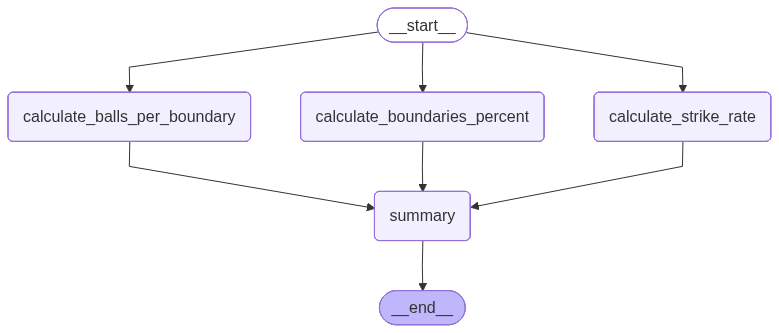

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [23]:
intial_state = BatsmanState(runs=120, balls=100, fours=10, sixes=5) # type: ignore
final_state = workflow.invoke(intial_state)
print(final_state['summary'])


    Strike Rate: 120.00
    Balls per Boundary: 6.67
    Boundaries Percent: 58.33%
    
